Data Preprocessing

Convert text to lowercase.
Remove punctuation, emojis, and stopwords.
Tokenize words (split sentences into words).
Use lemmatization to convert words into their base forms.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [4]:
from textblob import TextBlob

In [5]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer


In [6]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/taheeratanveer/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/taheeratanveer/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/taheeratanveer/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [7]:
df1 = pd.read_csv("post1.csv")
df2 = pd.read_csv("post2.csv")

In [8]:
print(df1.head())
print(df2.head())

   Unnamed: 0  Unnamed: 1               Name  Username   Profile ID  \
0           1         NaN     saksena_amayra       NaN  67005719535   
1           2         NaN       akhil_s_5520       NaN  27862917042   
2           3         NaN  aliveonthisplanet       NaN   6253347461   
3           4         NaN       pranay142023       NaN  60851965099   
4           5         NaN       pranay142023       NaN  60851965099   

                  Date  Likes  \
0  2024-06-18 10:36:57      0   
1  2024-06-19 12:00:10      0   
2  2024-06-19 14:48:55      0   
3  2024-06-19 17:36:17      0   
4  2024-06-19 17:38:13      0   

                                             Comment User Verified  \
0                                  Hahahahahahahahah            no   
1                                                 ❤️            no   
2  We need a movie with them 🔥♥️🔥♥️🔥♥️🔥♥️ #bringi...            no   
3                                         Honey 🍯🍯🍯🍯            no   
4                       

In [9]:
# Combine comments from both datasets
df_comments = pd.concat([df1[['Comment']], df2[['Comment']]], ignore_index=True)

# Handle missing values
df_comments.dropna(inplace=True)

In [10]:
# Function to perform sentiment analysis
def get_sentiment(text):
    analysis = TextBlob(str(text))  # Ensure text is a string
    if analysis.sentiment.polarity > 0:
        return "Positive"
    elif analysis.sentiment.polarity < 0:
        return "Negative"
    else:
        return "Neutral"


In [11]:
# Apply sentiment analysis
df_comments['Sentiment'] = df_comments['Comment'].apply(get_sentiment)


In [12]:
 #Display sentiment distribution
sentiment_counts = df_comments['Sentiment'].value_counts()

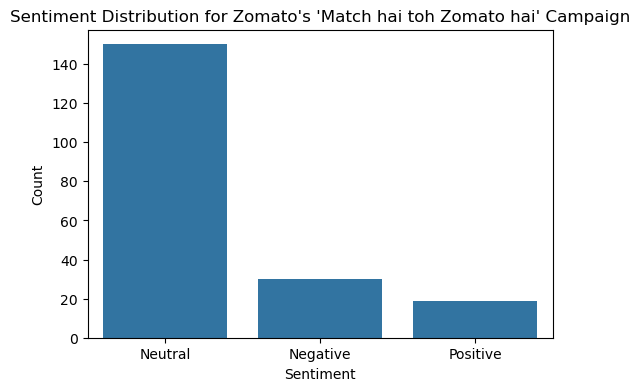

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Distribution for Zomato's 'Match hai toh Zomato hai' Campaign")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [14]:
# Export sentiment analysis results
df_comments.to_csv("Zomato_Sentiment_Analysis.csv", index=False)
print("Sentiment analysis completed! Results saved as 'Zomato_Sentiment_Analysis.csv'")

Sentiment analysis completed! Results saved as 'Zomato_Sentiment_Analysis.csv'


To

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation


In [17]:
# Basic text preprocessing function
def preprocess_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # Remove punctuation and numbers
    text = text.lower().strip()  # Convert to lowercase and strip whitespace
    return text

# Apply preprocessing to comments
df_comments['Processed_Comment'] = df_comments['Comment'].astype(str).apply(preprocess_text)


In [18]:
# Vectorization using CountVectorizer (Bag-of-Words)
vectorizer = CountVectorizer(max_features=500, stop_words='english')  # Using top 500 words
X = vectorizer.fit_transform(df_comments['Processed_Comment'])

In [19]:
# Apply Latent Dirichlet Allocation (LDA) for topic modeling
num_topics = 3  # Adjust based on dataset size
lda_model = LatentDirichletAllocation(n_components=num_topics, random_state=42)
lda_model.fit(X)


LatentDirichletAllocation(n_components=3, random_state=42)

In [20]:
# Get words per topic
def get_top_words(model, feature_names, n_top_words):
    topics = {}
    for topic_idx, topic in enumerate(model.components_):
        topics[f"Topic {topic_idx+1}"] = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
    return topics

In [24]:
# Extract top words for each topic
# Convert topics to DataFrame for better visualization
topics_df = pd.DataFrame.from_dict(topics, orient='index', columns=[f'Word {i+1}' for i in range(10)])

# Flatten the topics into a list of words
word_counts = pd.Series(topics_df.values.flatten())

In [26]:
# Convert topics to DataFrame for better visualization
topics_df = pd.DataFrame.from_dict(topics, orient='index', columns=[f'Word {i+1}' for i in range(10)])

word_frequencies = word_counts.value_counts().head(20)  # Get top 20 most frequent words


/var/folders/cf/34qhvjvx1kn547ps6tlnx4k40000gn/T/ipykernel_15422/108694058.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=word_frequencies.values, y=word_frequencies.index, palette="Blues_r")


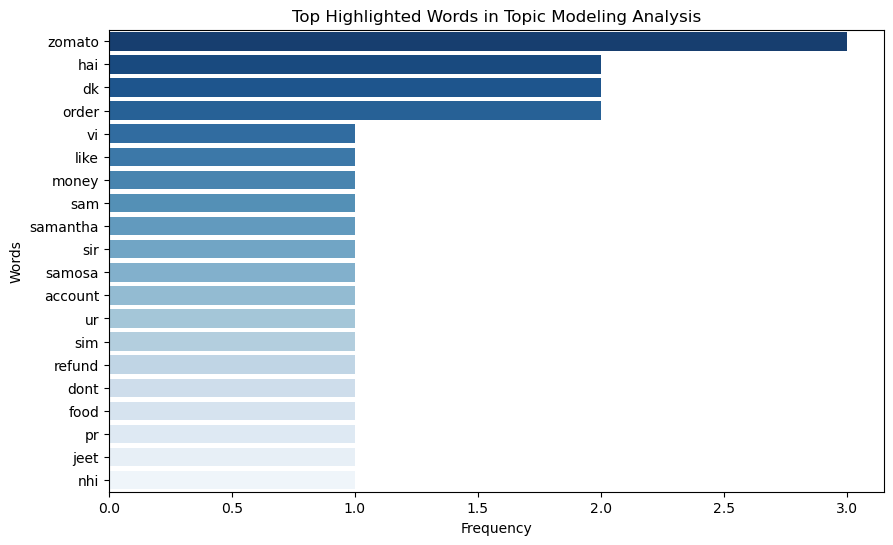


Topic modeling completed! Results saved as 'Zomato_Topic_Modeling.csv'.


In [28]:
# Plot the bar chart of most highlighted words
plt.figure(figsize=(10, 6))
sns.barplot(x=word_frequencies.values, y=word_frequencies.index, palette="Blues_r")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top Highlighted Words in Topic Modeling Analysis")
plt.show()

# Save topics to CSV
topics_df.to_csv("Zomato_Topic_Modeling.csv", index=True)
print("\nTopic modeling completed! Results saved as 'Zomato_Topic_Modeling.csv'.")

What This Heatmap Tells Us
Most words have low weights (dark blue), meaning they are not highly influential across topics.
A few words have slightly higher weights (lighter blue to red), showing their significance in those topics.
There is no clear separation between topics—this suggests that many words are shared across topics, which could mean:
The topics are closely related (e.g., different aspects of Zomato's campaign).
The preprocessing may need stopword removal refinement to filter irrelevant words.
We might need to increase the number of topics to get more separation.
